# Information in the yield curve: Multidynamic Model

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from quantpy.math.curve import MultidynamicModel

plt.style.use('seaborn-v0_8-whitegrid')
example_root = Path(os.path.abspath(""))

## Data loading

In [20]:
curve1_date  = "2026-02-27"
curve1_color = "royalblue"
curve2_date  = "2026-03-06"
curve2_color = "indianred"

In [21]:
yields1_df = pd.read_csv(example_root / "data" / f"fi_yields_{curve1_date}.csv")
yields2_df = pd.read_csv(example_root / "data" / f"fi_yields_{curve2_date}.csv")

## Curve fitting

In [23]:
curve1_model = MultidynamicModel(yields1_df["ZeroYield"].to_numpy(), yields1_df["TimeToMaturity"].to_numpy(), init_params=[0.4, 0.04, 0.02, 0.02, 0.01, 0.005], method="dogbox", ftol=1e-8, xtol=1e-8, gtol=1e-8, max_nfev=100_000)
curve2_model = MultidynamicModel(yields2_df["ZeroYield"].to_numpy(), yields2_df["TimeToMaturity"].to_numpy(), init_params=[0.4, 0.04, 0.02, 0.02, 0.01, 0.005], method="dogbox", ftol=1e-8, xtol=1e-8, gtol=1e-8, max_nfev=100_000)

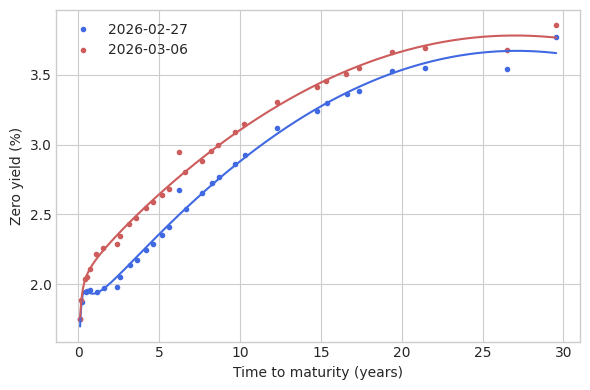

In [35]:
tt = np.linspace(yields2_df["TimeToMaturity"].min(), yields1_df["TimeToMaturity"].max(), 1000)

fig = plt.figure(figsize=(6, 4))

plt.plot(yields1_df["TimeToMaturity"], yields1_df["ZeroYield"] * 100, linestyle='None', marker='.', label=curve1_date, color=curve1_color)
plt.plot(yields2_df["TimeToMaturity"], yields2_df["ZeroYield"] * 100, linestyle='None', marker='.', label=curve2_date, color=curve2_color)
plt.plot(tt, curve1_model(tt) * 100, linestyle='-', color=curve1_color)
plt.plot(tt, curve2_model(tt) * 100, linestyle='-', color=curve2_color)

plt.xlabel("Time to maturity (years)")
plt.ylabel("Zero yield (%)")

plt.legend()
fig.tight_layout()
fig.savefig(example_root / "figures" / "07_date_comp.pdf")
plt.show()

In [27]:
print(f"Params for date {curve1_date}:", curve1_model.params)
print(f"Params for date {curve2_date}:", curve2_model.params)

Params for date 2026-02-27: {'tau': np.float64(0.1315485506407924), 'beta_0': np.float64(0.016611992432955396), 'beta_1': np.float64(-0.005071034530595345), 'beta_2': np.float64(0.0146749202800174), 'beta_3': np.float64(0.0014779084292979407), 'beta_4': np.float64(2.7222246717424442e-05)}
Params for date 2026-03-06: {'tau': np.float64(0.05612699790397269), 'beta_0': np.float64(0.02078845772325023), 'beta_1': np.float64(-0.00760651381408931), 'beta_2': np.float64(2.6110238287261593e-06), 'beta_3': np.float64(0.0012633765786428533), 'beta_4': np.float64(2.3410671034431188e-05)}


## Forward curve breakdowns

In [38]:
def long_term(beta_0: float, m: np.ndarray[float]) -> np.ndarray[float]:
  """Long term component of the forward curve"""
  return np.array([beta_0] * len(m))


def short_term(tau: float, beta_1: float, m: np.ndarray[float]) -> np.ndarray[float]:
  """Short term component of the forward curve"""
  return beta_1 * np.exp(-m / tau)


def medium_term(tau: float, beta_2: float, m: np.ndarray[float]) -> np.ndarray[float]:
  """Medium term component of the forward curve"""
  return beta_2 / tau * m * np.exp(-m / tau)


def risk_premia_term(beta_3: float, m: np.ndarray[float]) -> np.ndarray[float]:
  """Risk premia term component of the forward curve"""
  return 2. * beta_3 * m


def convexity_term(beta_4: float, m: np.ndarray[float]) -> np.ndarray[float]:
  """Convexity term component of the forward curve"""
  return -3. * beta_4 * np.pow(m, 2.)

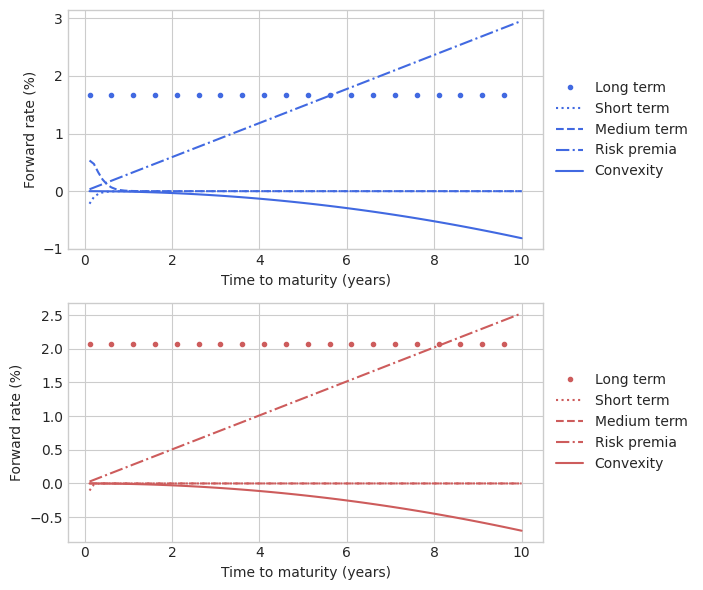

In [55]:
tt = np.linspace(yields2_df["TimeToMaturity"].min(), 10, 100)

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(7, 6))

axs[0].plot(tt[::5], long_term(curve1_model.params["beta_0"], tt[::5]) * 100, linestyle='None', marker='.', color=curve1_color, label="Long term")
axs[0].plot(tt, short_term(curve1_model.params["tau"], curve1_model.params["beta_1"], tt) * 100, linestyle='dotted', color=curve1_color, label="Short term")
axs[0].plot(tt, medium_term(curve1_model.params["tau"], curve1_model.params["beta_2"], tt) * 100, linestyle='dashed', color=curve1_color, label="Medium term")
axs[0].plot(tt, risk_premia_term(curve1_model.params["beta_3"], tt) * 100, linestyle='dashdot', color=curve1_color, label="Risk premia")
axs[0].plot(tt, convexity_term(curve1_model.params["beta_4"], tt) * 100, linestyle='-', color=curve1_color, label="Convexity")

axs[0].set_xlabel("Time to maturity (years)")
axs[0].set_ylabel("Forward rate (%)")
axs[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))

axs[1].plot(tt[::5], long_term(curve2_model.params["beta_0"], tt[::5]) * 100, linestyle='None', marker='.', color=curve2_color, label="Long term")
axs[1].plot(tt, short_term(curve2_model.params["tau"], curve2_model.params["beta_1"], tt) * 100, linestyle='dotted', color=curve2_color, label="Short term")
axs[1].plot(tt, medium_term(curve2_model.params["tau"], curve2_model.params["beta_2"], tt) * 100, linestyle='dashed', color=curve2_color, label="Medium term")
axs[1].plot(tt, risk_premia_term(curve2_model.params["beta_3"], tt) * 100, linestyle='dashdot', color=curve2_color, label="Risk premia")
axs[1].plot(tt, convexity_term(curve2_model.params["beta_4"], tt) * 100, linestyle='-', color=curve2_color, label="Convexity")

axs[1].set_xlabel("Time to maturity (years)")
axs[1].set_ylabel("Forward rate (%)")
axs[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))

fig.tight_layout()
fig.savefig(example_root / "figures" / "07_forward_breakdown.pdf")
plt.show()